Made to inspect models that have been trained.

## Libraries

In [1]:
from pathlib import Path
import sys

ROOT_DIR = Path.cwd()
while not (ROOT_DIR / "models").exists():
    ROOT_DIR = ROOT_DIR.parent
sys.path.insert(0, str(ROOT_DIR))

import csv
import matplotlib.pyplot as plt
import torch
import numpy as np
from pathlib import Path
from training.dataset import BRICKDataset
from models.brick import BRICK
import pandas as pd

## Functions

In [11]:
# ================================================================================
# FUNCTIONS
# ================================================================================

def list_runs(results_root: Path, subfolder: str = None) -> list:
    """List all runs in results/training or a named subfolder."""
    search_root = results_root / subfolder if subfolder else results_root
    csv_files = sorted(search_root.glob("*/loss_history.csv"))
    if not csv_files:
        raise FileNotFoundError(f"No loss_history.csv found in {search_root}")
    print(f"Available runs in '{subfolder or 'root'}':")
    for i, f in enumerate(csv_files):
        print(f"  [{i+1}] {f.parent.name}")
    return csv_files


def load_csv(csv_path: Path) -> dict:
    """Load loss history CSV into lists."""
    data = {k: [] for k in [
        "epochs",
        "train_total", "val_total",
        "train_recon", "val_recon",
        "train_kl_g0", "val_kl_g0",
        "train_kl_u",  "val_kl_u",
        "train_cls",   "val_cls",
    ]}
    with open(csv_path) as f:
        for row in csv.DictReader(f):
            data["epochs"].append(int(row["epoch"]))
            data["train_total"].append(float(row["train_loss_total"]))
            data["val_total"].append(float(row["val_loss_total"]))
            data["train_recon"].append(float(row["train_loss_recon"]))
            data["val_recon"].append(float(row["val_loss_recon"]))
            data["train_kl_g0"].append(float(row["train_loss_kl_g0"]))
            data["val_kl_g0"].append(float(row["val_loss_kl_g0"]))
            data["train_kl_u"].append(float(row["train_loss_kl_u"]))
            data["val_kl_u"].append(float(row["val_loss_kl_u"]))
            data["train_cls"].append(float(row["train_loss_cls"]))
            data["val_cls"].append(float(row["val_loss_cls"]))
    return data


def load_best_epoch(csv_path: Path) -> int | None:
    """Load the best epoch from the checkpoint in the same directory."""
    checkpoint_path = csv_path.parent / "best_model_cls_preoverfit.pt"
    if checkpoint_path.exists():
        checkpoint = torch.load(checkpoint_path, map_location="cpu")
        best_epoch = checkpoint["epoch"]
        print(f"Best model saved at epoch {best_epoch}")
        return best_epoch
    print("No best_model.pt found.")
    return None


def plot_curves(data: dict, best_epoch: int | None, run_name: str, out_path: Path,
                 y_max: float | None = None):
    """Plot all loss curves and save to file."""
    epochs = data["epochs"]

    def plot(ax, title, train, val=None, apply_ymax=False):
        ax.plot(epochs, train, label="train", linewidth=1.5)
        if val is not None:
            ax.plot(epochs, val, label="val", linewidth=1.5, linestyle="--")
        if best_epoch is not None:
            ax.axvline(x=best_epoch, color='red', linestyle=':', linewidth=1.5,
                       label=f"best (ep {best_epoch})")
        if apply_ymax and y_max is not None:
            ax.set_ylim(0, y_max)
        ax.set_title(title)
        ax.set_xlabel("Epoch")
        ax.legend()
        ax.grid(alpha=0.3)

    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    fig.suptitle(f"BRICK Training Loss Curves\n{run_name}", fontsize=13)

    plot(axes[0, 0], "Total Loss",          data["train_total"],  data["val_total"],  apply_ymax=True)
    plot(axes[0, 1], "Reconstruction Loss", data["train_recon"],  data["val_recon"],  apply_ymax=True)
    plot(axes[0, 2], "KL g0",               data["train_kl_g0"],  data["val_kl_g0"])
    plot(axes[1, 0], "KL u",                data["train_kl_u"],   data["val_kl_u"])
    plot(axes[1, 1], "Classification Loss", data["train_cls"],    data["val_cls"])
    axes[1, 2].axis("off")

    plt.tight_layout()
    out_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    print(f"Saved to {out_path}")
    plt.show()


def plot_ablation(results_root: Path, subfolder: str, out_path: Path):
    """Plot all runs in a subfolder overlaid on the same axes."""
    csv_files = list_runs(results_root, subfolder=subfolder)

    fig, axes = plt.subplots(5, 2, figsize=(14, 20))
    fig.suptitle(f"BRICK Ablation Comparison\n{subfolder}", fontsize=13)

    def plot(ax_train, ax_val, title, key_train, key_val):
        for csv_path in csv_files:
            data = load_csv(csv_path)
            label = csv_path.parent.name
            ax_train.plot(data["epochs"], data[key_train], label=label, linewidth=1.2)
            ax_val.plot(data["epochs"],   data[key_val],   label=label, linewidth=1.2)
        ax_train.set_title(f"{title} — train")
        ax_val.set_title(f"{title} — val")
        for ax in (ax_train, ax_val):
            ax.set_xlabel("Epoch")
            ax.legend(fontsize=7)
            ax.grid(alpha=0.3)

    plot(axes[0, 0], axes[0, 1], "Total Loss",          "train_total",  "val_total")
    plot(axes[1, 0], axes[1, 1], "Reconstruction Loss", "train_recon",  "val_recon")
    plot(axes[2, 0], axes[2, 1], "KL g0",               "train_kl_g0",  "val_kl_g0")
    plot(axes[3, 0], axes[3, 1], "KL u",                "train_kl_u",   "val_kl_u")
    plot(axes[4, 0], axes[4, 1], "Classification Loss", "train_cls",    "val_cls")

    plt.tight_layout()
    out_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    print(f"Saved to {out_path}")
    plt.show()

## PLOT

Available runs in 'ablation_2_batch_size_1':
  [1] ablation_full
  [2] ablation_no_control
  [3] ablation_no_control_no_ic
  [4] ablation_no_ic

Plotting: ablation_full
Best model saved at epoch 475
Saved to c:\Users\USER\Documents\GitHub\LIFUS-BRICK\results\figures\training_curves_ablation_full.png


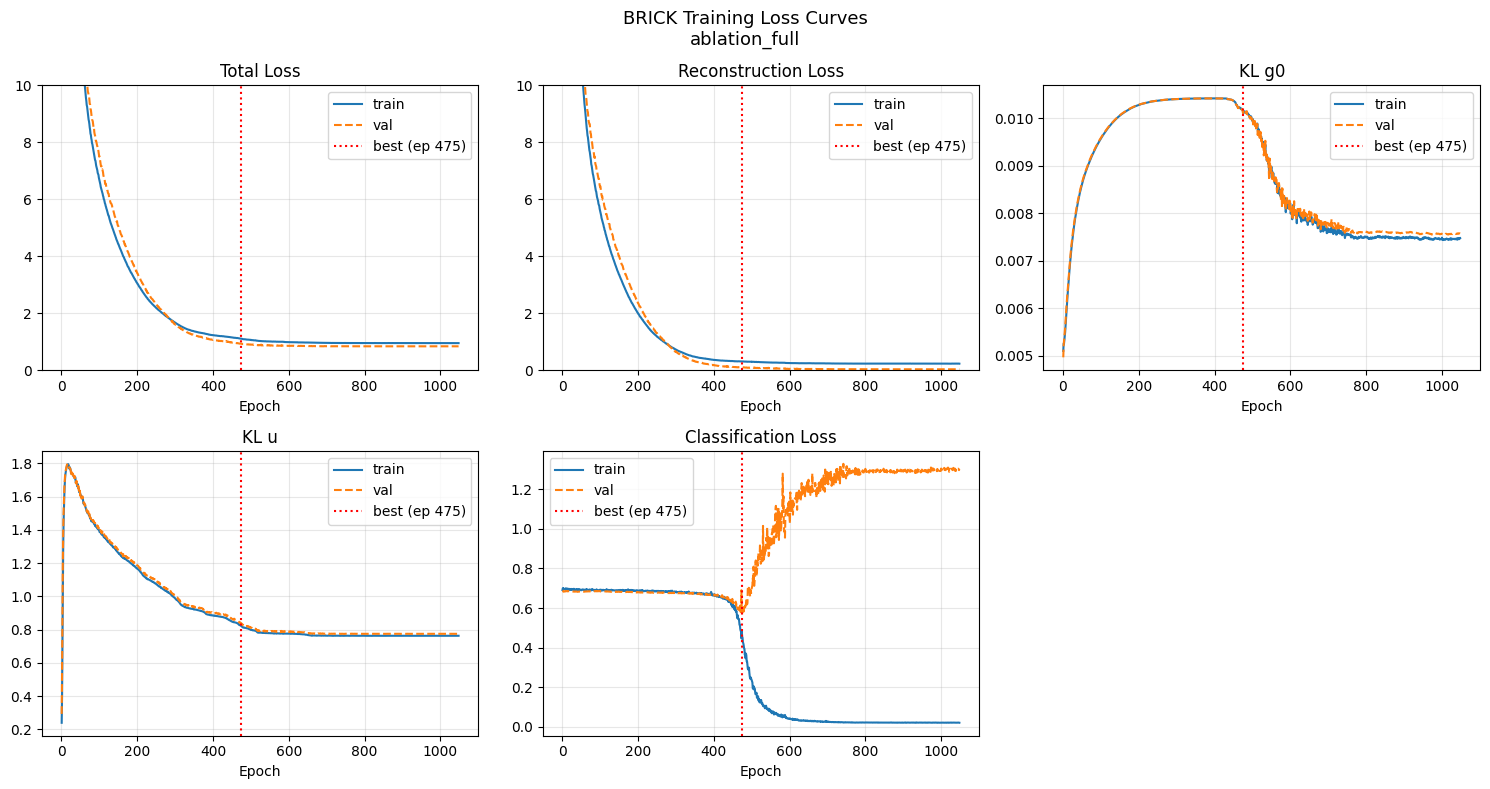


Run                            Best Val Recon     Best Val Cls    Epoch   
---------------------------------------------------------------------------
ablation_full                  0.1054             0.5743          475     
ablation_no_control            147.7345           0.0000          1       
ablation_no_control_no_ic      49.7917            0.0000          1       
ablation_no_ic                 0.1016             0.5951          475     


In [14]:
TRAIN_NUMBER = 1  # <-- change this
SUBFOLDER = "ablation_2_batch_size_1"  # e.g. "sweep_1", "ablation_BETA=0", or None for root

results_root = ROOT_DIR / "results" / "training"

csv_files  = list_runs(results_root, subfolder=SUBFOLDER)
csv_path   = csv_files[TRAIN_NUMBER - 1]
print(f"\nPlotting: {csv_path.parent.name}")

data       = load_csv(csv_path)
best_epoch = load_best_epoch(csv_path)
out_path   = ROOT_DIR / "results" / "figures" / f"training_curves_{csv_path.parent.name}.png"

plot_curves(data, best_epoch, csv_path.parent.name, out_path, y_max=10)

# --- Preoverfit-only comparison table (all runs in SUBFOLDER) ---
print(f"\n{'Run':<30} {'Best Val Recon':<18} {'Best Val Cls':<15} {'Epoch':<8}")
print("-" * 75)
for cp in csv_files:
    df = pd.read_csv(cp)
    run_name = cp.parent.name

    preoverfit_path = cp.parent / "best_model_cls_preoverfit.pt"
    if not preoverfit_path.exists():
        print(f"{run_name:<30} [no preoverfit checkpoint]")
        continue

    ckpt = torch.load(preoverfit_path, map_location="cpu")
    pre_epoch = ckpt["epoch"]
    row = df[df["epoch"] == pre_epoch].iloc[0]
    print(f"{run_name:<30} {float(row['val_loss_recon']):<18.4f} "
          f"{float(row['val_loss_cls']):<15.4f} {pre_epoch:<8}")

Available runs in 'Test_beta':
  [1] ablation_no_ic_BETA=0
  [2] ablation_no_ic_BETA=0.1
Best model saved at epoch 3395
Best model saved at epoch 2969
Best model saved at epoch 3395
Best model saved at epoch 2969
Best model saved at epoch 3395
Best model saved at epoch 2969
Best model saved at epoch 3395
Best model saved at epoch 2969
Best model saved at epoch 3395
Best model saved at epoch 2969


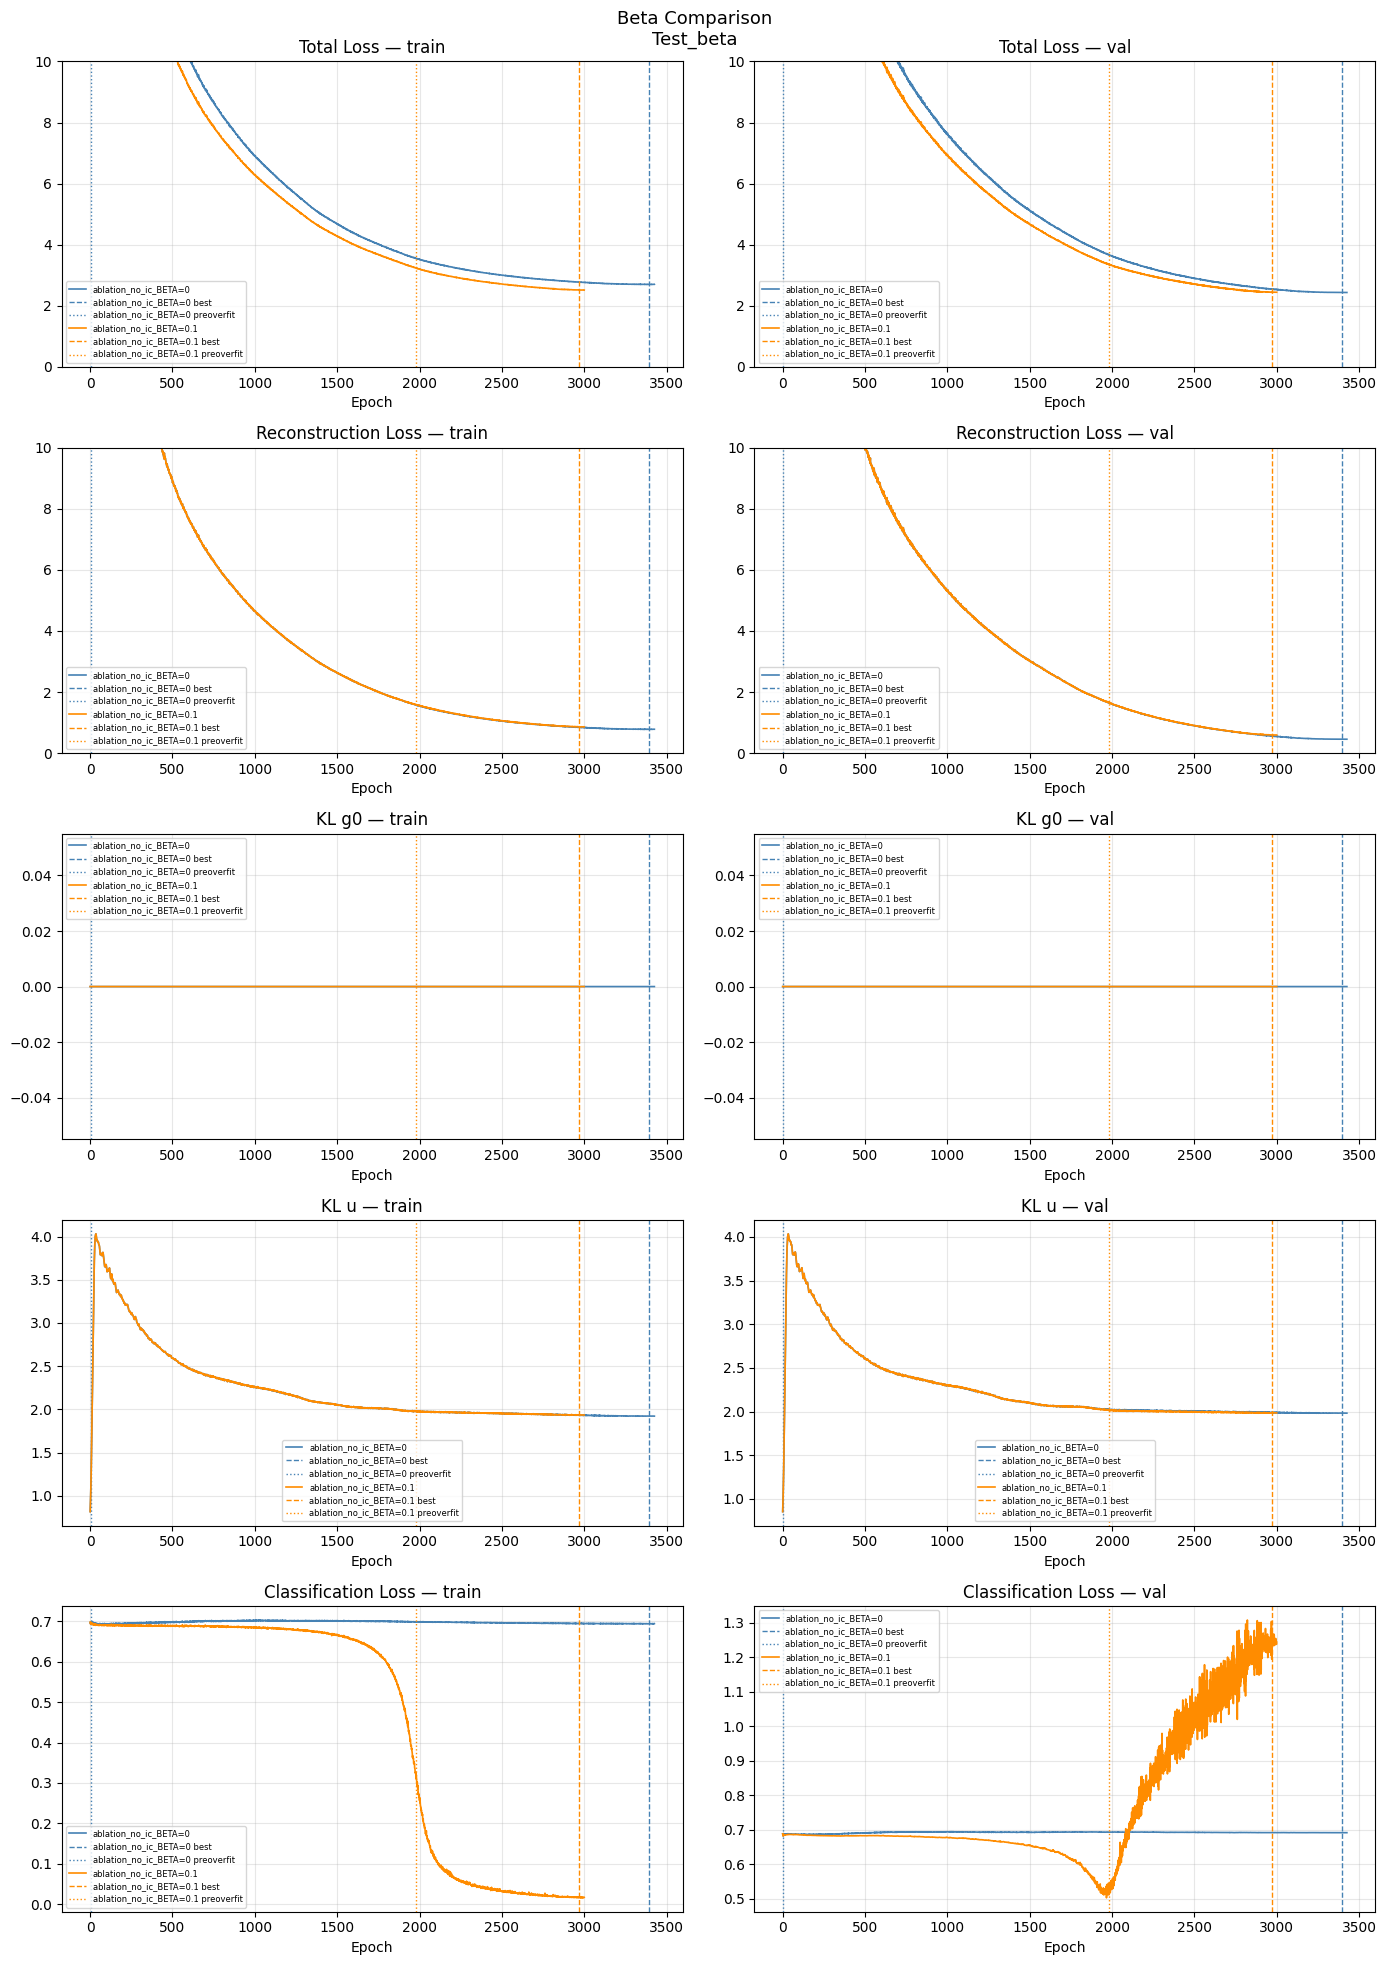


Run                            Checkpoint      Best Val Recon     Best Val Cls    Epoch   
------------------------------------------------------------------------------------------
Best model saved at epoch 3395
ablation_no_ic_BETA=0          best            0.4567             0.6911          3395    
  preoverfit_path exists: True
ablation_no_ic_BETA=0          preoverfit      75.4712            0.6815          4       

Best model saved at epoch 2969
ablation_no_ic_BETA=0.1        best            0.5973             1.1947          2969    
  preoverfit_path exists: True
ablation_no_ic_BETA=0.1        preoverfit      1.6501             0.5102          1980    



In [17]:
#DO WE USE BETA

def plot_beta_comparison(results_root: Path, subfolder: str):
    """
    Plot both runs in subfolder, each with both best and preoverfit checkpoints marked.
    Also prints a comparison table.
    """
    csv_files = list_runs(results_root, subfolder=subfolder)

    fig, axes = plt.subplots(5, 2, figsize=(14, 20))
    fig.suptitle(f"Beta Comparison\n{subfolder}", fontsize=13)

    colors = {"ablation_no_ic_BETA=0": "steelblue", "ablation_no_ic_BETA=0.1": "darkorange"}

    def plot(ax_train, ax_val, title, key_train, key_val, ylim=None):

        if ylim is not None:
            ax_train.set_ylim(ylim)
            ax_val.set_ylim(ylim)
        
        for csv_path in csv_files:
            data      = load_csv(csv_path)
            run_name  = csv_path.parent.name
            color     = colors.get(run_name, "gray")

            ax_train.plot(data["epochs"], data[key_train], label=run_name, color=color, linewidth=1.2)
            ax_val.plot(data["epochs"],   data[key_val],   label=run_name, color=color, linewidth=1.2)

            # Mark best_model.pt epoch
            best_epoch = load_best_epoch(csv_path)
            if best_epoch:
                for ax, key in [(ax_train, key_train), (ax_val, key_val)]:
                    ax.axvline(x=best_epoch, color=color, linestyle="--", linewidth=1.0,
                               label=f"{run_name} best")

            # Mark best_model_preoverfit.pt epoch
            preoverfit_path = csv_path.parent / "best_model_cls_preoverfit.pt"
            if preoverfit_path.exists():
                ckpt = torch.load(preoverfit_path, map_location="cpu")
                pre_epoch = ckpt["epoch"]
                for ax in (ax_train, ax_val):
                    ax.axvline(x=pre_epoch, color=color, linestyle=":", linewidth=1.0,
                               label=f"{run_name} preoverfit")

        ax_train.set_title(f"{title} — train")
        ax_val.set_title(f"{title} — val")
        for ax in (ax_train, ax_val):
            ax.set_xlabel("Epoch")
            ax.legend(fontsize=6)
            ax.grid(alpha=0.3)

    plot(axes[0, 0], axes[0, 1], "Total Loss",          "train_total",  "val_total",  ylim=(0, 10))
    plot(axes[1, 0], axes[1, 1], "Reconstruction Loss", "train_recon",  "val_recon",  ylim=(0, 10))
    plot(axes[2, 0], axes[2, 1], "KL g0",               "train_kl_g0",  "val_kl_g0")
    plot(axes[3, 0], axes[3, 1], "KL u",                "train_kl_u",   "val_kl_u")
    plot(axes[4, 0], axes[4, 1], "Classification Loss", "train_cls",    "val_cls")

    plt.tight_layout()
    plt.show()

    # --- Comparison table ---
    print(f"\n{'Run':<30} {'Checkpoint':<15} {'Best Val Recon':<18} {'Best Val Cls':<15} {'Epoch':<8}")
    print("-" * 90)
    for csv_path in csv_files:
        df = pd.read_csv(csv_path)
        run_name = csv_path.parent.name

        # best_model.pt
        best_epoch = load_best_epoch(csv_path)
        if best_epoch:
            row = df[df["epoch"] == best_epoch].iloc[0]
            print(f"{run_name:<30} {'best':<15} {float(row['val_loss_recon']):<18.4f} "
                  f"{float(row['val_loss_cls']):<15.4f} {best_epoch:<8}")

        # best_model_preoverfit.pt
        preoverfit_path = csv_path.parent / "best_model_cls_preoverfit.pt"
        print(f"  preoverfit_path exists: {preoverfit_path.exists()}")

        if preoverfit_path.exists():
            ckpt = torch.load(preoverfit_path, map_location="cpu")
            pre_epoch = ckpt["epoch"]
            row = df[df["epoch"] == pre_epoch].iloc[0]
            print(f"{run_name:<30} {'preoverfit':<15} {float(row['val_loss_recon']):<18.4f} "
                  f"{float(row['val_loss_cls']):<15.4f} {pre_epoch:<8}")
        print()

plot_beta_comparison(
    results_root=ROOT_DIR / "results" / "training",
    subfolder="Test_beta",
)

In [21]:
import pandas as pd
from pathlib import Path

ROOT_DIR = Path(r"C:\Users\USER\Documents\GitHub\LIFUS-BRICK")
df = pd.read_csv(ROOT_DIR / "results" / "final_model" / "cls_preoverfit" / "statistical_results_roi_zi.csv")
df["sign_mismatch"] = (df["delta"] > 0) != (df["t_statistic"] > 0)
print(df[["roi_name", "delta", "t_statistic", "sign_mismatch"]])

df_vim = pd.read_csv(ROOT_DIR / "results" / "final_model" / "cls_preoverfit" / "statistical_results_roi_vim.csv")
df_vim["sign_mismatch"] = (df_vim["delta"] > 0) != (df_vim["t_statistic"] > 0)
print(df_vim[["roi_name", "delta", "t_statistic", "sign_mismatch"]])

                        roi_name     delta  t_statistic  sign_mismatch
0                          lh_Ca -0.000036     0.337314           True
1                         lh_GPe -0.000164     0.820177           True
2                         lh_GPi -0.000440     1.557860           True
3                          lh_Pu -0.000674     2.604363           True
4                         lh_STH -0.000125     0.704585           True
5          lh_cerebellum_dentate  0.000146    -0.670685           True
6            lh_cerebellum_motor -0.000146     0.592753           True
7       lh_paracentral_smooth3mm -0.000251     0.891362           True
8       lh_postcentral_smooth3mm -0.000534     2.404085           True
9        lh_precentral_smooth3mm -0.000674     2.451652           True
10  lh_superiorfrontal_smooth3mm -0.000337     1.138046           True
11                        lh_vim -0.000703     2.246129           True
12                         lh_zi -0.000098     0.529801           True
13    

Available runs in 'TandM_check':
  [1] TandM_check
Available runs in 'TandM_check_noic':
  [1] TandM_check_noic
Best model saved at epoch 1627
Best model saved at epoch 2102
Best model saved at epoch 1627
Best model saved at epoch 2102
Best model saved at epoch 1627
Best model saved at epoch 2102
Best model saved at epoch 1627
Best model saved at epoch 2102
Best model saved at epoch 1627
Best model saved at epoch 2102


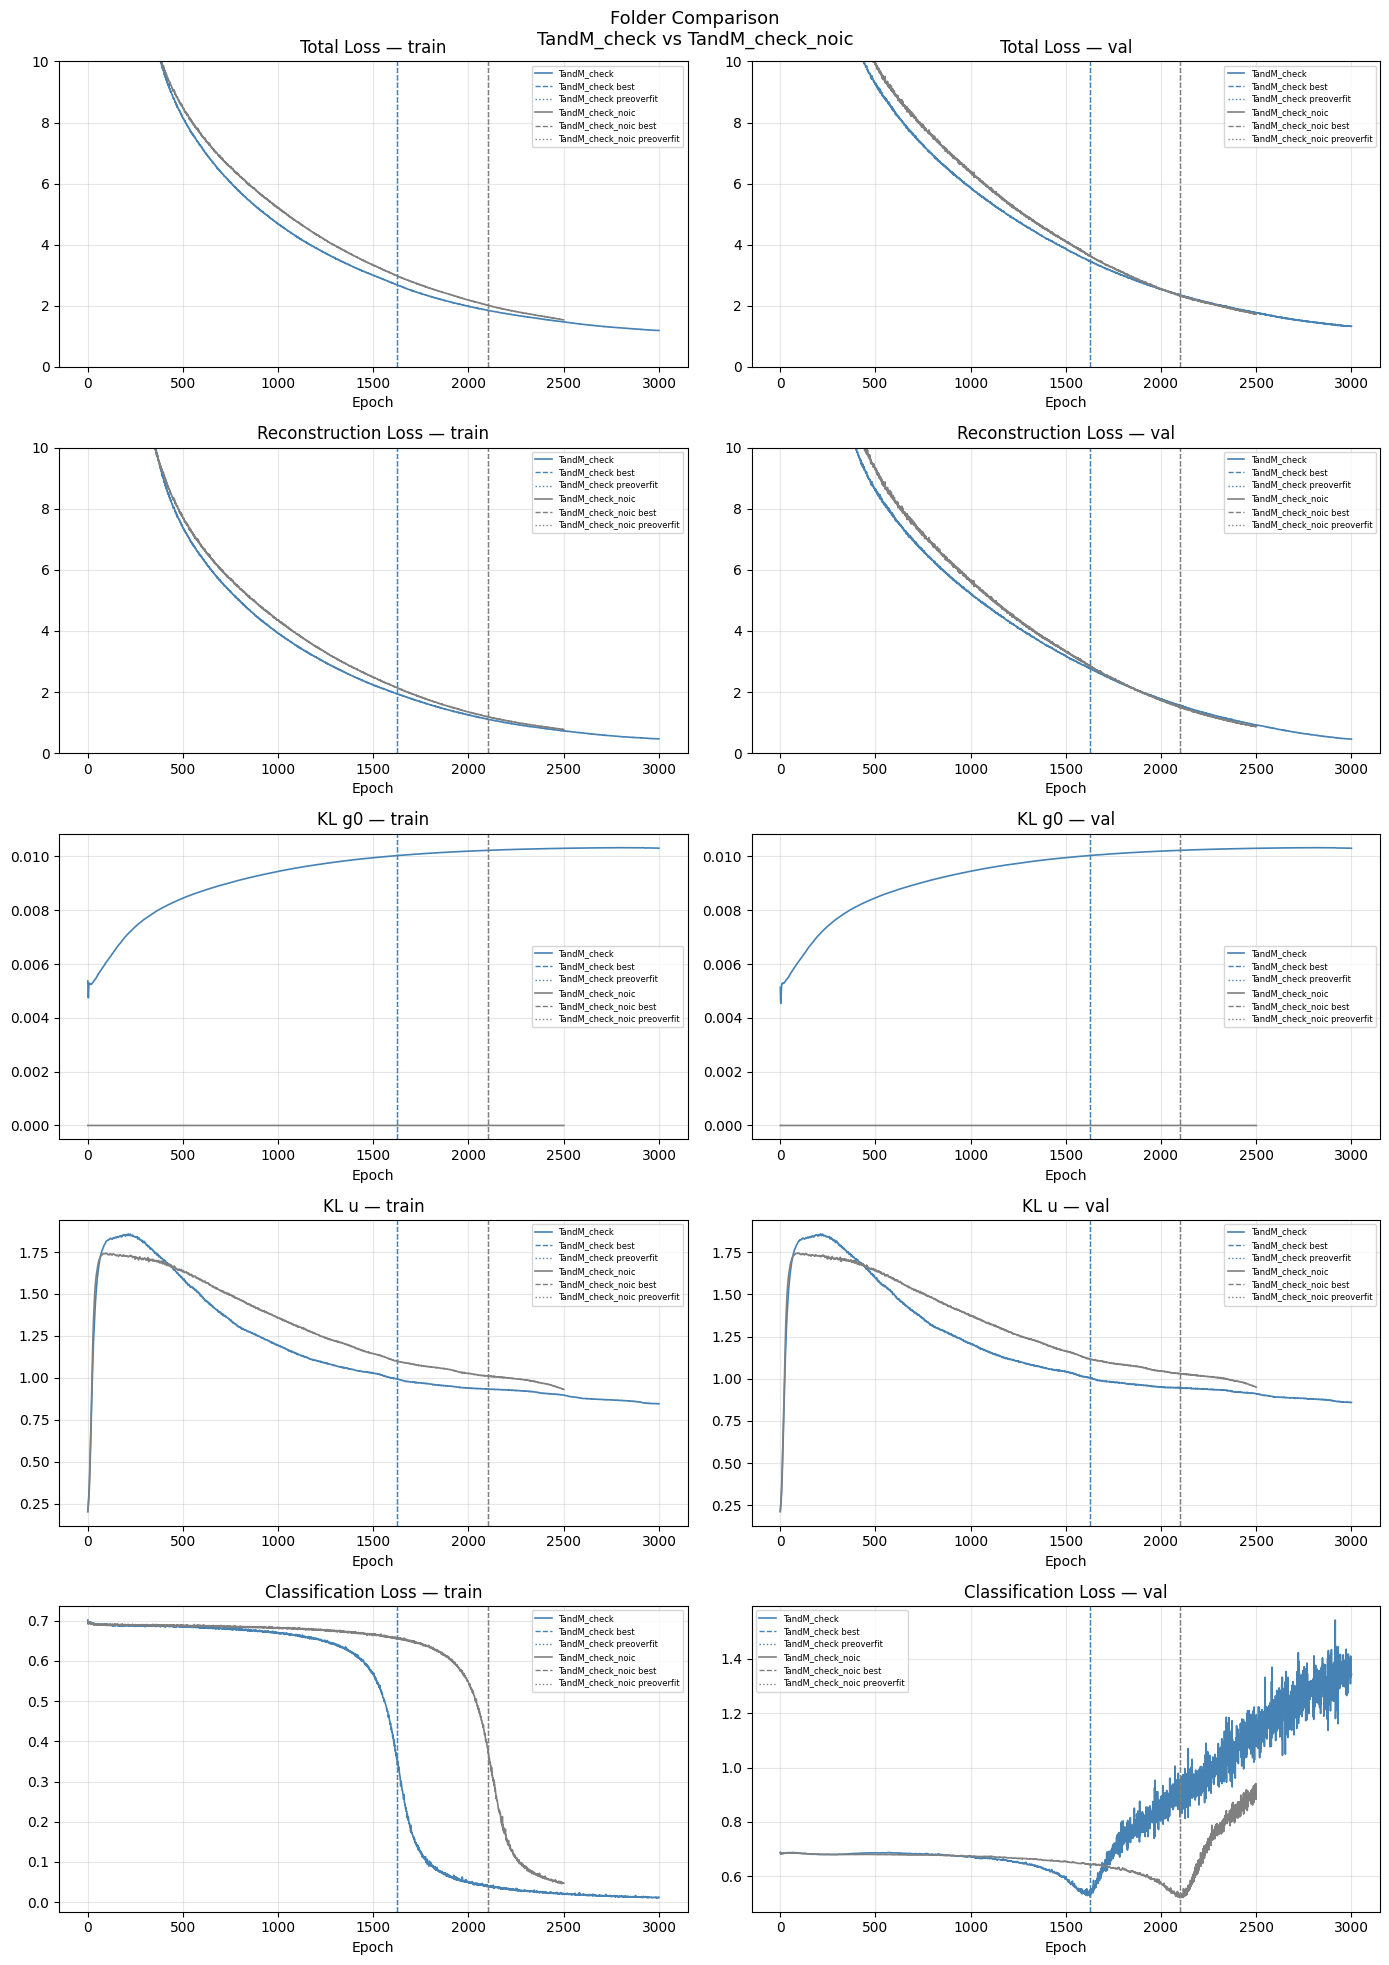


Folder               Checkpoint      Best Val Recon     Best Val Cls    Epoch   
------------------------------------------------------------------------------------------
Best model saved at epoch 1627
TandM_check          best            2.7744             0.5255          1627    
  preoverfit_path exists: True
TandM_check          preoverfit      2.7744             0.5255          1627    

Best model saved at epoch 2102
TandM_check_noic     best            1.5103             0.5212          2102    
  preoverfit_path exists: True
TandM_check_noic     preoverfit      1.5103             0.5212          2102    



In [20]:
def list_runs(results_root: Path, subfolder: str = None):
    """
    List all runs in results/training or a named subfolder.
    Handles two layouts:
      1. Flat:   subfolder/loss_history.csv           (one run)
      2. Nested: subfolder/run_name/loss_history.csv  (one or more runs)
    """
    search_root = results_root / subfolder if subfolder else results_root

    if not search_root.exists():
        raise FileNotFoundError(f"{search_root} does not exist")

    # Case 1: CSV sits directly in search_root -> treat search_root as the run
    direct_csv = search_root / "loss_history.csv"
    if direct_csv.exists():
        csv_files = [direct_csv]
    else:
        # Case 2: look one level down for run subfolders containing the CSV
        csv_files = sorted(search_root.glob("*/loss_history.csv"))

    if not csv_files:
        raise FileNotFoundError(f"No loss_history.csv found in {search_root}")

    print(f"Available runs in '{subfolder or 'root'}':")
    for i, f in enumerate(csv_files):
        print(f"  [{i+1}] {f.parent.name}")

    return csv_files

def plot_folder_comparison(results_root: Path, subfolders: list):
    """
    Plot runs from multiple subfolders on the same axes, each with
    best and preoverfit checkpoints marked.
    """
    # gather (csv_path, subfolder_label) pairs across all requested subfolders
    csv_entries = []
    for sf in subfolders:
        for csv_path in list_runs(results_root, subfolder=sf):
            csv_entries.append((csv_path, sf))

    fig, axes = plt.subplots(5, 2, figsize=(14, 20))
    fig.suptitle(f"Folder Comparison\n{' vs '.join(subfolders)}", fontsize=13)

    colors = {"TandM_check": "steelblue", "TM_check": "darkorange"}

    def plot(ax_train, ax_val, title, key_train, key_val, ylim=None):

        if ylim is not None:
            ax_train.set_ylim(ylim)
            ax_val.set_ylim(ylim)

        for csv_path, label in csv_entries:
            data  = load_csv(csv_path)
            color = colors.get(label, "gray")

            ax_train.plot(data["epochs"], data[key_train], label=label, color=color, linewidth=1.2)
            ax_val.plot(data["epochs"],   data[key_val],   label=label, color=color, linewidth=1.2)

            # Mark best_model.pt epoch
            best_epoch = load_best_epoch(csv_path)
            if best_epoch:
                for ax in (ax_train, ax_val):
                    ax.axvline(x=best_epoch, color=color, linestyle="--", linewidth=1.0,
                               label=f"{label} best")

            # Mark best_model_cls_preoverfit.pt epoch
            preoverfit_path = csv_path.parent / "best_model_cls_preoverfit.pt"
            if preoverfit_path.exists():
                ckpt = torch.load(preoverfit_path, map_location="cpu")
                pre_epoch = ckpt["epoch"]
                for ax in (ax_train, ax_val):
                    ax.axvline(x=pre_epoch, color=color, linestyle=":", linewidth=1.0,
                               label=f"{label} preoverfit")

        ax_train.set_title(f"{title} — train")
        ax_val.set_title(f"{title} — val")
        for ax in (ax_train, ax_val):
            ax.set_xlabel("Epoch")
            ax.legend(fontsize=6)
            ax.grid(alpha=0.3)

    plot(axes[0, 0], axes[0, 1], "Total Loss",          "train_total",  "val_total",  ylim=(0, 10))
    plot(axes[1, 0], axes[1, 1], "Reconstruction Loss", "train_recon",  "val_recon",  ylim=(0, 10))
    plot(axes[2, 0], axes[2, 1], "KL g0",               "train_kl_g0",  "val_kl_g0")
    plot(axes[3, 0], axes[3, 1], "KL u",                "train_kl_u",   "val_kl_u")
    plot(axes[4, 0], axes[4, 1], "Classification Loss", "train_cls",    "val_cls")

    plt.tight_layout()
    plt.show()

    # --- Comparison table ---
    print(f"\n{'Folder':<20} {'Checkpoint':<15} {'Best Val Recon':<18} {'Best Val Cls':<15} {'Epoch':<8}")
    print("-" * 90)
    for csv_path, label in csv_entries:
        df = pd.read_csv(csv_path)

        best_epoch = load_best_epoch(csv_path)
        if best_epoch:
            row = df[df["epoch"] == best_epoch].iloc[0]
            print(f"{label:<20} {'best':<15} {float(row['val_loss_recon']):<18.4f} "
                  f"{float(row['val_loss_cls']):<15.4f} {best_epoch:<8}")

        preoverfit_path = csv_path.parent / "best_model_cls_preoverfit.pt"
        print(f"  preoverfit_path exists: {preoverfit_path.exists()}")

        if preoverfit_path.exists():
            ckpt = torch.load(preoverfit_path, map_location="cpu")
            pre_epoch = ckpt["epoch"]
            row = df[df["epoch"] == pre_epoch].iloc[0]
            print(f"{label:<20} {'preoverfit':<15} {float(row['val_loss_recon']):<18.4f} "
                  f"{float(row['val_loss_cls']):<15.4f} {pre_epoch:<8}")
        print()


plot_folder_comparison(
    results_root=ROOT_DIR / "results" / "training",
    subfolders=["TandM_check", "TandM_check_noic"],
)

Plot Ablation

Available runs in 'ablation_2_batch_size_1':
  [1] ablation_full
  [2] ablation_no_control
  [3] ablation_no_control_no_ic
  [4] ablation_no_ic

Plotting: ablation_no_control
Best model saved at epoch 41
Available runs in 'ablation_2_batch_size_1':
  [1] ablation_full
  [2] ablation_no_control
  [3] ablation_no_control_no_ic
  [4] ablation_no_ic
Saved to c:\Users\USER\Documents\GitHub\LIFUS-BRICK\results\figures\comparison_ablation_2_batch_size_1.png


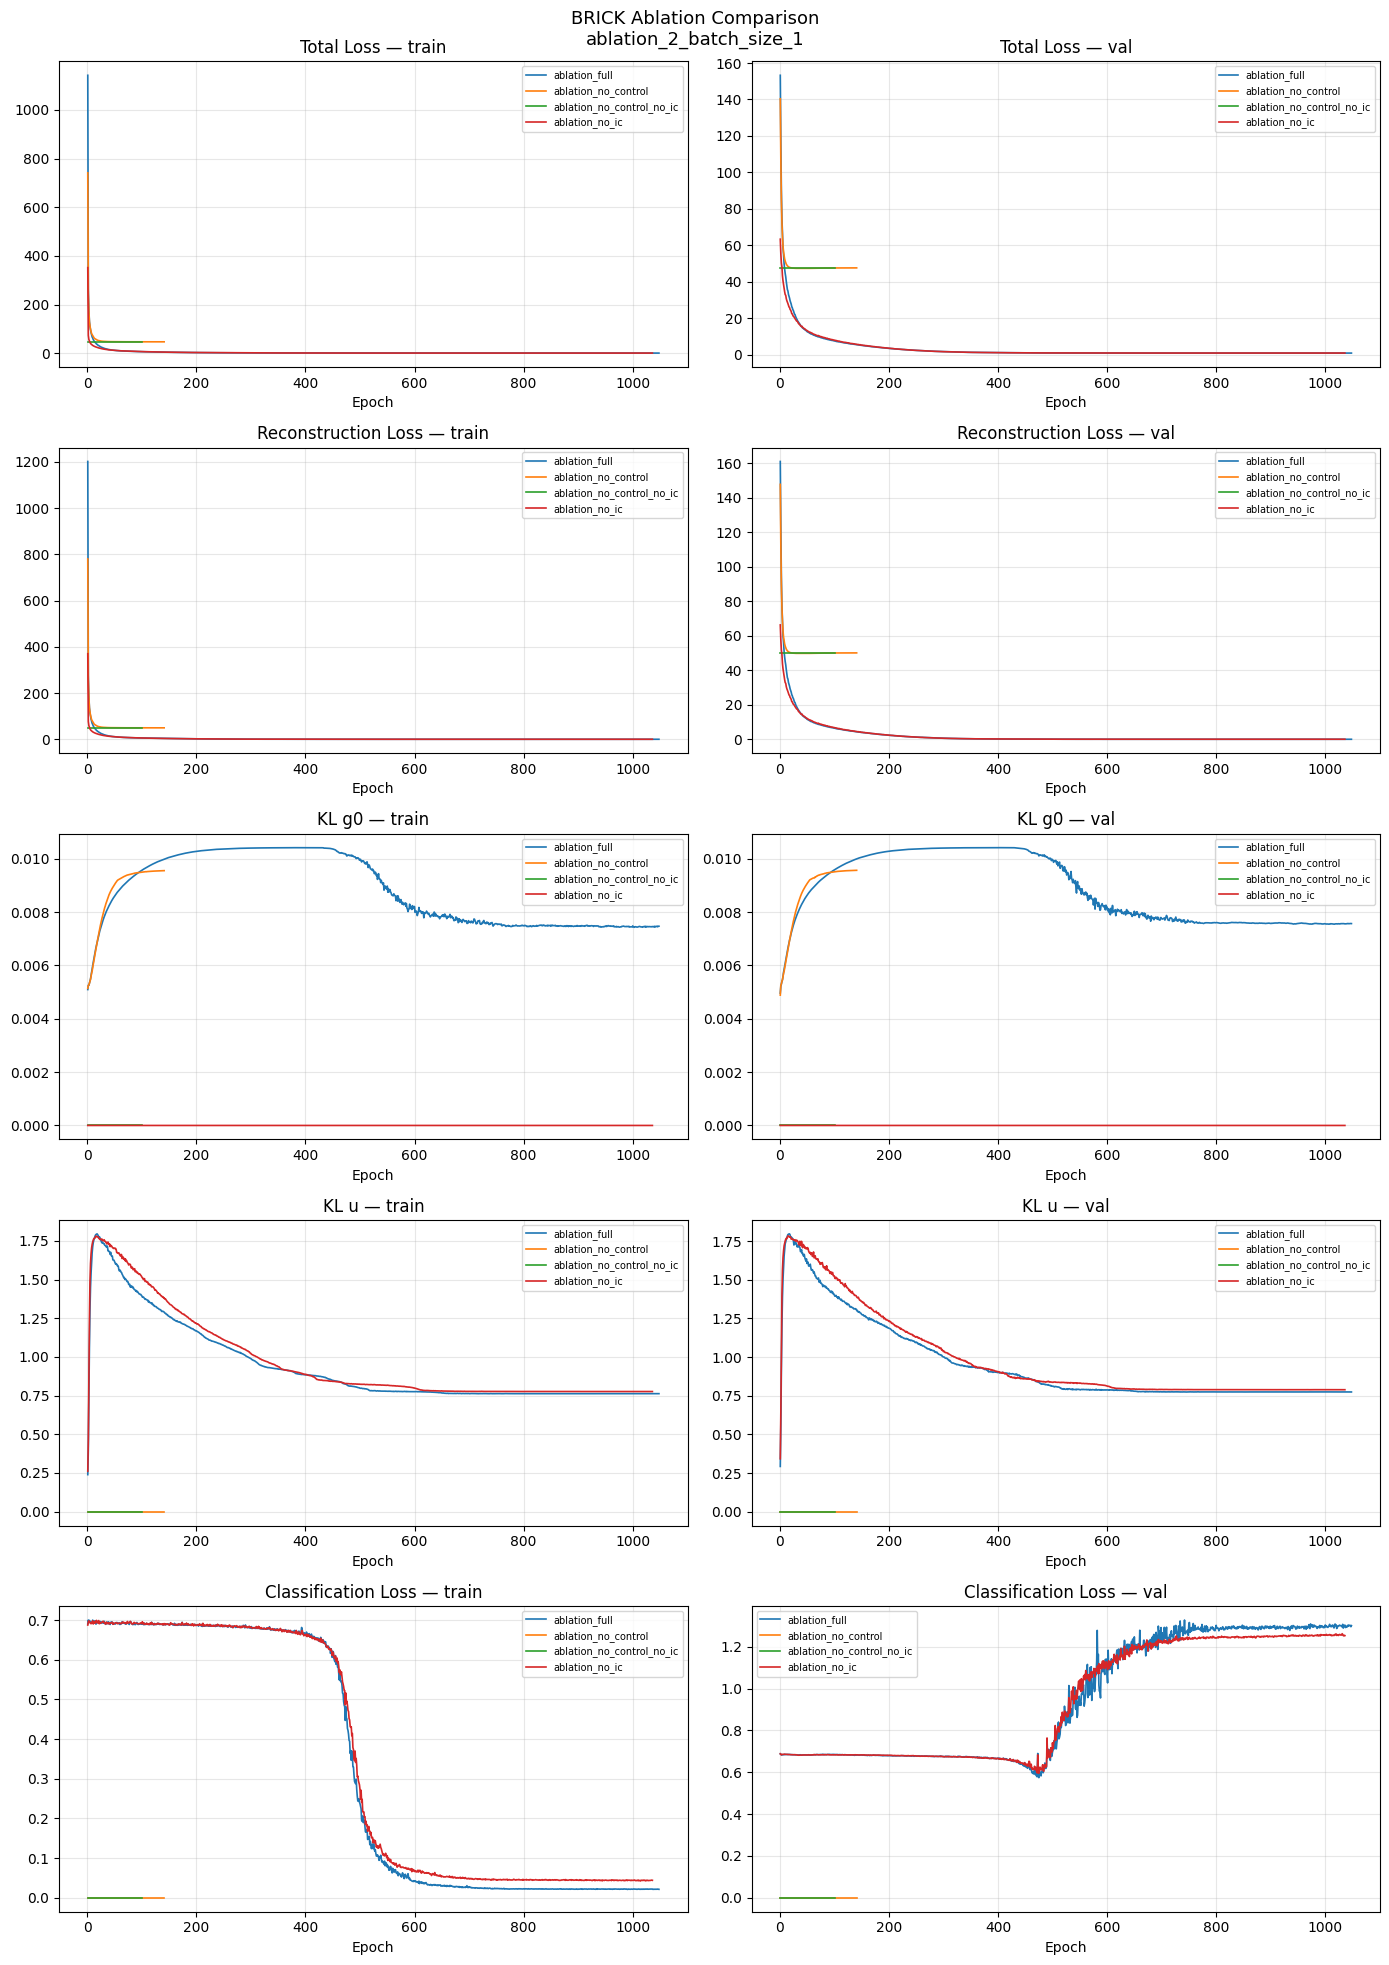

In [3]:
TRAIN_NUMBER = 2  # <-- change this
SUBFOLDER = "ablation_2_batch_size_1"  # e.g. "sweep_1", "ablation_BETA=0", or None for root

results_root = ROOT_DIR / "results" / "training"

csv_files  = list_runs(results_root, subfolder=SUBFOLDER)
csv_path   = csv_files[TRAIN_NUMBER - 1]
print(f"\nPlotting: {csv_path.parent.name}")

data       = load_csv(csv_path)
best_epoch = load_best_epoch(csv_path)
out_path   = ROOT_DIR / "results" / "figures" / f"training_curves_{csv_path.parent.name}.png"

plot_ablation(
    results_root=ROOT_DIR / "results" / "training",
    subfolder="ablation_2_batch_size_1",
    out_path=ROOT_DIR / "results" / "figures" / "comparison_ablation_2_batch_size_1.png"
)

### Test Load Model

In [ ]:
import torch
from models.brick import BRICK

checkpoint = torch.load("results/training/your_run_name/best_model.pt")

model = BRICK(
    use_control=checkpoint["use_control"],
    use_ic=checkpoint["use_ic"],
    h=checkpoint["h"],
    m=checkpoint["m"],
)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

### Test for VAE posterior collapse vs code bug (grdients not flowing properly)

In [7]:
import torch
from training.dataset import BRICKDataset
from models.brick import BRICK
from pathlib import Path

ds = BRICKDataset(Path("data/preprocessed_data"))

checkpoint = torch.load("results/training/train_20260619_134312/best_model.pt", map_location="cpu")
model = BRICK(use_control=True, use_ic=True, h=2, nhead=2)
model.load_state_dict(checkpoint["model_state_dict"])
model.train()

x     = ds[0]["x"]
label = ds[0]["lifus_condition"]
out   = model(x, label)
out["losses"]["loss_total"].backward()

print("Encoder gradients:")
for name, param in model.encoder.named_parameters():
    if param.grad is not None:
        print(f"  {name}: grad_norm={param.grad.norm().item():.6f}")
    else:
        print(f"  {name}: NO GRADIENT")

Encoder gradients:
  row_mlp.0.weight: grad_norm=0.000000
  row_mlp.0.bias: grad_norm=0.000000
  row_mlp.2.weight: grad_norm=0.000000
  row_mlp.2.bias: grad_norm=0.000000
  mu_head.layers.0.self_attn.in_proj_weight: grad_norm=0.000000
  mu_head.layers.0.self_attn.in_proj_bias: grad_norm=0.000000
  mu_head.layers.0.self_attn.out_proj.weight: grad_norm=0.000000
  mu_head.layers.0.self_attn.out_proj.bias: grad_norm=0.000000
  mu_head.layers.0.linear1.weight: grad_norm=0.000000
  mu_head.layers.0.linear1.bias: grad_norm=0.000000
  mu_head.layers.0.linear2.weight: grad_norm=0.000000
  mu_head.layers.0.linear2.bias: grad_norm=0.000000
  mu_head.layers.0.norm1.weight: grad_norm=0.000000
  mu_head.layers.0.norm1.bias: grad_norm=0.000000
  mu_head.layers.0.norm2.weight: grad_norm=0.000083
  mu_head.layers.0.norm2.bias: grad_norm=0.000083
  mu_head.layers.1.self_attn.in_proj_weight: grad_norm=0.000056
  mu_head.layers.1.self_attn.in_proj_bias: grad_norm=0.000040
  mu_head.layers.1.self_attn.out_

This is vanishing gradients in the early layers — a secondary issue on top of posterior collapse. The first row_mlp and first transformer layer are essentially not learning because gradients diminish as they backpropagate through the network.
This is expected behavior for a collapsed VAE — when mu≈0 and sigma≈1 (prior), the KL gradient is near zero, so very little signal flows back through the encoder. It's a consequence of collapse, not an independent bug.
Conclusion: No code bug. The collapse is genuine VAE behavior caused by the loss landscape. KL annealing is the right fix — it forces reconstruction gradients to flow through the encoder before KL pressure can cause collapse, which would give the early layers a chance to learn.